In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
df = pd.read_csv('country_wise_latest.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (187, 15)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    str    
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    str    
dtype

In [5]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000


In [6]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [7]:
df['New recovered'] = df['New recovered'].fillna(0)

print("Missing values handled.")

Missing values handled.


In [8]:
df['Active_Ratio'] = df['Active'] / df['Confirmed']

df['Recovery_Rate'] = df['Recovered'] / df['Confirmed']

df['Mortality_Rate'] = df['Deaths'] / df['Confirmed']

df['Weekly_Growth_Rate'] = df['1 week % increase']

df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Active_Ratio,Recovery_Rate,Mortality_Rate,Weekly_Growth_Rate
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,0.270138,0.694868,0.034994,2.07
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,0.407992,0.562500,0.029508,17.00
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0.285025,0.673399,0.041576,18.07
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,0.057332,0.885336,0.057332,2.60
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,0.702105,0.254737,0.043158,26.84


In [9]:
df = df.replace([np.inf, -np.inf], np.nan)

df = df.fillna(0)

print("Data cleaned successfully.")

Data cleaned successfully.


In [10]:
feature_columns = [
    'Confirmed',
    'Deaths',
    'Recovered',
    'Active',
    'Deaths / 100 Cases',
    'Recovered / 100 Cases',
    'Active_Ratio',
    'Recovery_Rate',
    'Mortality_Rate',
    '1 week % increase'
]

X = df[feature_columns]

X.head()

,Confirmed,Deaths,Recovered,Active,Deaths / 100 Cases,Recovered / 100 Cases,Active_Ratio,Recovery_Rate,Mortality_Rate,1 week % increase
0,36263,1269,25198,9796,3.50,69.49,0.270138,0.694868,0.034994,2.07
1,4880,144,2745,1991,2.95,56.25,0.407992,0.562500,0.029508,17.00
2,27973,1163,18837,7973,4.16,67.34,0.285025,0.673399,0.041576,18.07
3,907,52,803,52,5.73,88.53,0.057332,0.885336,0.057332,2.60
4,950,41,242,667,4.32,25.47,0.702105,0.254737,0.043158,26.84


In [11]:
top10 = df.nlargest(10,'Confirmed')

top10[['Country/Region','Confirmed']]

,Country/Region,Confirmed
173,US,4290259
23,Brazil,2442375
79,India,1480073
138,Russia,816680
154,South Africa,452529
111,Mexico,395489
132,Peru,389717
35,Chile,347923
177,United Kingdom,301708
81,Iran,293606


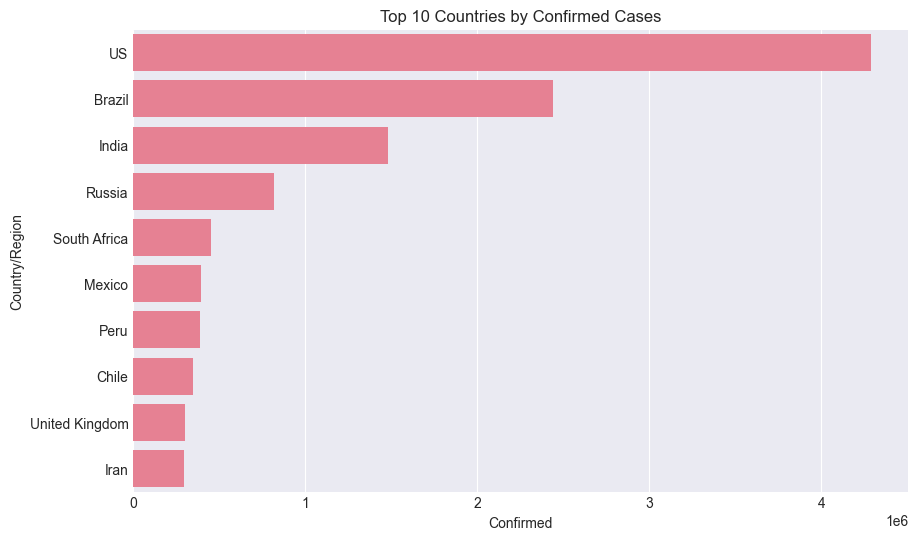

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    y='Country/Region',
    x='Confirmed'
)

plt.title('Top 10 Countries by Confirmed Cases')

plt.show()

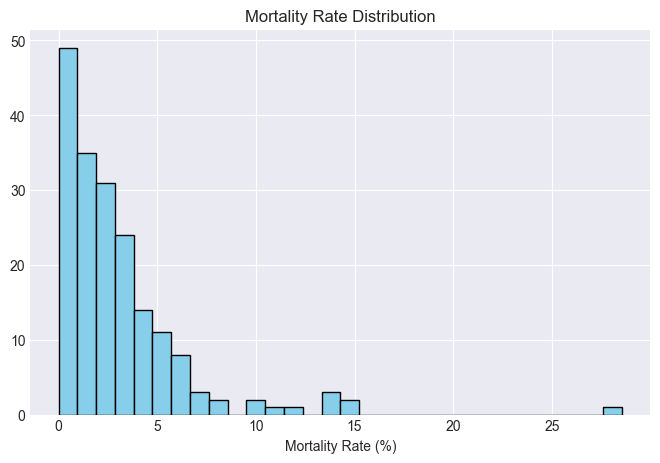

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Mortality_Rate']*100,
    bins=30,
    color='skyblue',
    edgecolor='black'
)

plt.title("Mortality Rate Distribution")

plt.xlabel("Mortality Rate (%)")

plt.show()

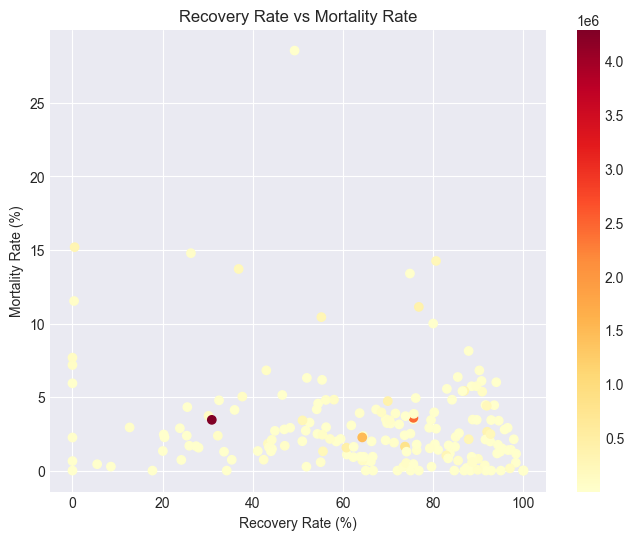

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Recovery_Rate']*100,
    df['Mortality_Rate']*100,
    c=df['Confirmed'],
    cmap='YlOrRd'
)

plt.colorbar()

plt.xlabel("Recovery Rate (%)")
plt.ylabel("Mortality Rate (%)")

plt.title("Recovery Rate vs Mortality Rate")

plt.show()

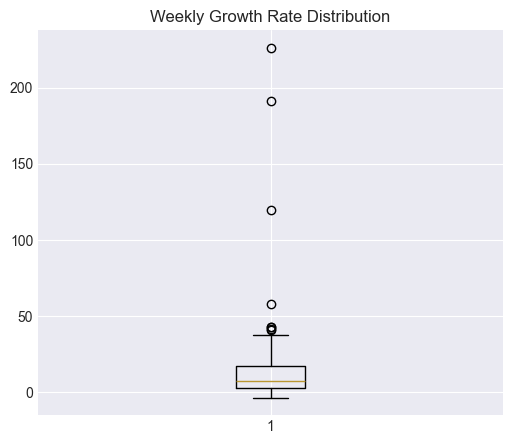

In [15]:
plt.figure(figsize=(6,5))

plt.boxplot(
    df['1 week % increase'].dropna()
)

plt.title("Weekly Growth Rate Distribution")

plt.show()

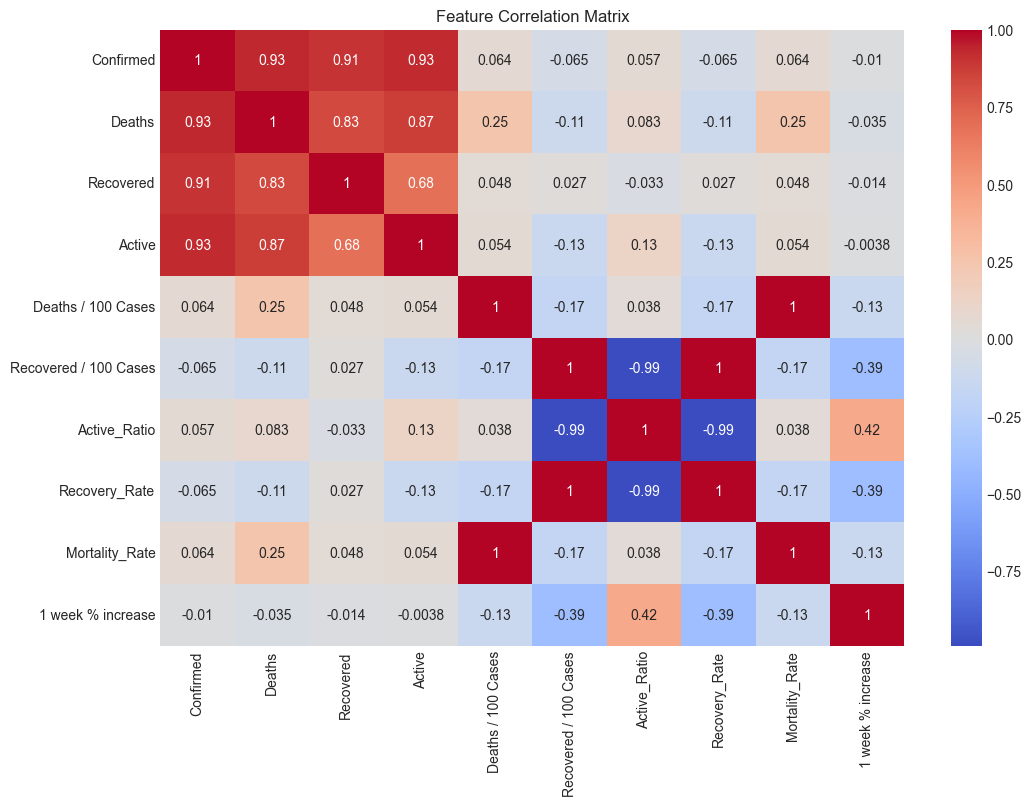

In [16]:
corr = X.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(187, 10)


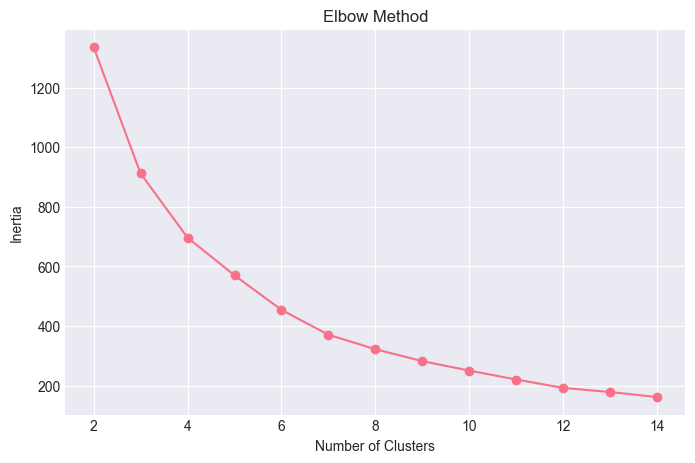

In [18]:
inertias = []

for k in range(2,15):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertias,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

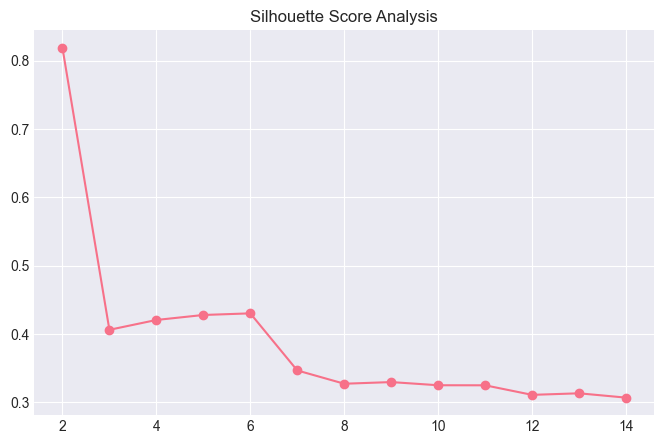

In [19]:
scores = []

for k in range(2,15):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores,
    marker='o'
)

plt.title("Silhouette Score Analysis")

plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df[['Country/Region','KMeans_Cluster']].head()

,Country/Region,KMeans_Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,2
3,Andorra,2
4,Angola,0


In [21]:
df.groupby(
    'KMeans_Cluster'
)[['Confirmed','Deaths','Recovered']].mean()

,Confirmed,Deaths,Recovered
KMeans_Cluster,,,
0,3.098143e+04,1033.065574,1.270261e+04
1,3.366317e+06,117814.500000,1.586222e+06
2,5.474563e+04,1345.278261,4.142219e+04
3,1.735818e+05,22298.111111,8.413678e+04


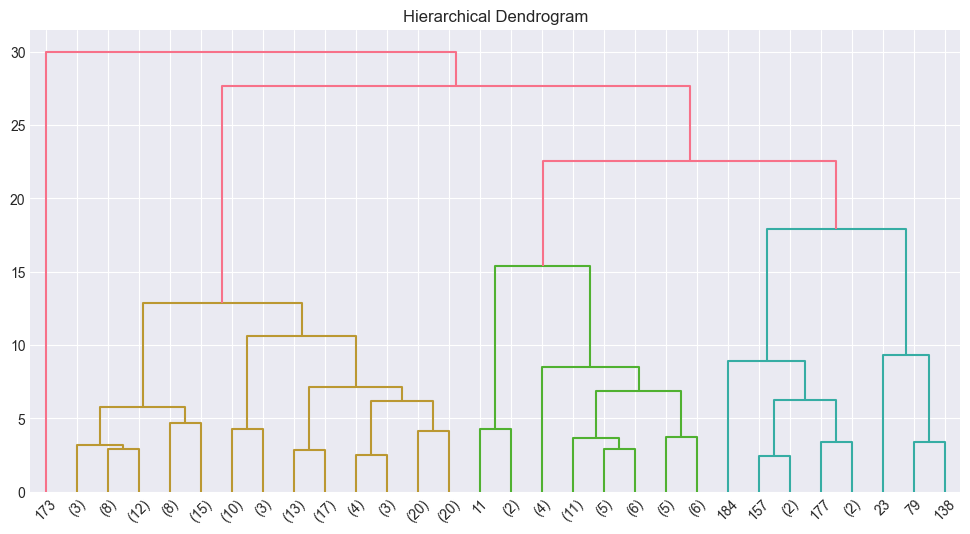

In [22]:
Z = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Dendrogram")

plt.show()

In [23]:
hier_labels = fcluster(
    Z,
    4,
    criterion='maxclust'
)

df['Hierarchical_Cluster'] = hier_labels

df[['Country/Region','Hierarchical_Cluster']].head()

,Country/Region,Hierarchical_Cluster
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Andorra,1
4,Angola,2


In [24]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df[['Country/Region','DBSCAN_Cluster']].head()

,Country/Region,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Andorra,0
4,Angola,-1


In [25]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    112
-1     70
 1      5
Name: count, dtype: int64

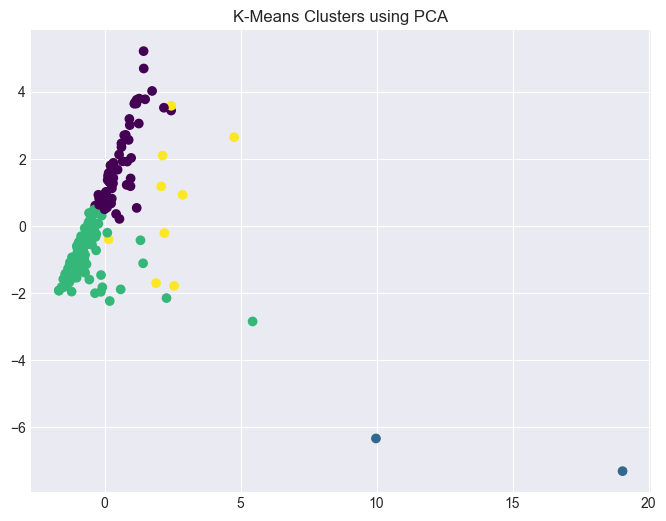

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['KMeans_Cluster'],
    cmap='viridis'
)

plt.title("K-Means Clusters using PCA")

plt.show()

In [27]:
comparison = pd.DataFrame({
    'Country': df['Country/Region'],
    'KMeans': df['KMeans_Cluster'],
    'Hierarchical': df['Hierarchical_Cluster'],
    'DBSCAN': df['DBSCAN_Cluster']
})

comparison.head(20)

,Country,KMeans,Hierarchical,DBSCAN
0,Afghanistan,2,1,0
1,Albania,0,1,0
2,Algeria,2,1,0
3,Andorra,2,1,0
4,Angola,0,2,-1
5,Antigua and Barbuda,2,1,0
6,Argentina,0,2,-1
7,Armenia,2,1,0
8,Australia,2,1,0
9,Austria,2,1,0


In [28]:
df.to_csv(
    'covid_clustering_results.csv',
    index=False
)

print("Results Saved Successfully")

Results Saved Successfully
